In [211]:
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy


In [159]:
t_obs = 1*30*24*60*60.0
nu_range=np.arange(-277.76*10**-6,277.76*10**-6,1/t_obs)
nu_range_custom= np.linspace(-277.76*10**-6,277.76*10**-6,100000)
# np.sinc(3.14*nu_range*t_obs)
# 1/t_obs
nu_range.shape
# 3.14*nu_range*t_obs

(1440,)

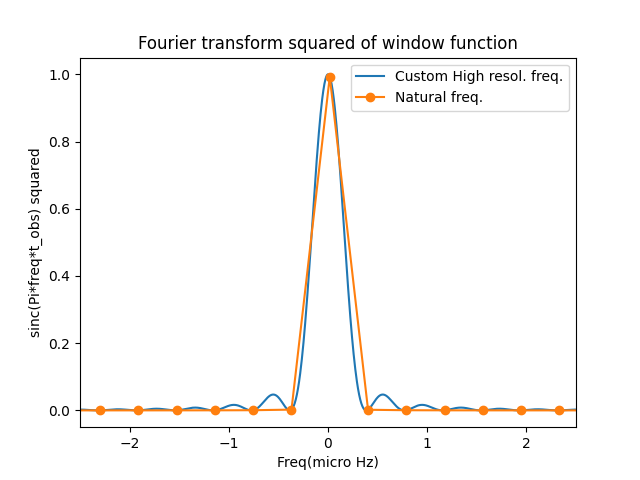

In [162]:
%matplotlib widget
plt.figure()
plt.plot(nu_range_custom*10**6,np.sinc(nu_range_custom*t_obs)**2,label = 'Custom High resol. freq.')
plt.plot(nu_range*10**6,np.sinc(nu_range*t_obs)**2,'-o',label = 'Natural freq.')
plt.ylabel('sinc(Pi*freq*t_obs) squared')
plt.xlabel('Freq(micro Hz)')
plt.title('Fourier transform squared of window function')
plt.legend()
plt.xlim(-2.5,2.5)
plt.show()

In [179]:
def lpeak(x,x0,h,fwhm):
    return h*(fwhm/2)**2/((x-x0)**2+(fwhm/2)**2)


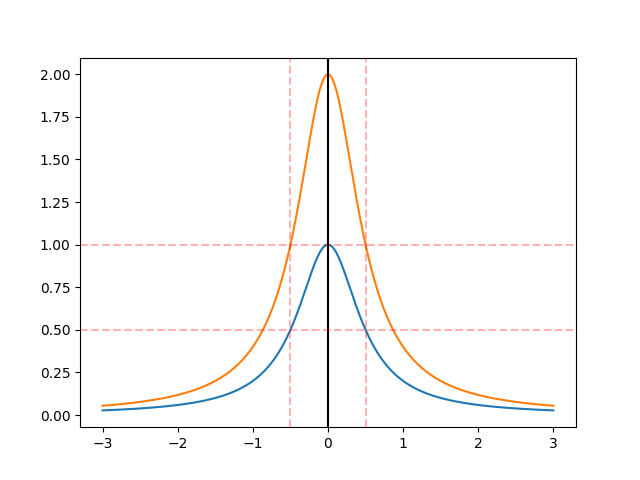

In [191]:
prange = np.linspace(-3,3,400)
plt.figure()
plt.plot(prange,lpeak(prange,0,1,1))
plt.plot(prange,lpeak(prange,0,2,1))
plt.axvline(0,color='k')
plt.axvline(-1/2,color='r',linestyle='--',alpha=0.3)
plt.axvline(1/2,color='r',linestyle='--',alpha=0.3)
plt.axhline(1,color='r',linestyle='--',alpha=0.3)
plt.axhline(1/2,color='r',linestyle='--',alpha=0.3)
plt.show()

In [482]:
def exp_decay(t,a=1,nu0=100*1e-6,tau=np.inf):
    return a*np.exp(-t/tau)*np.sin(2*np.pi*nu0*t)

In [483]:
print(exp_decay(np.array([0,0.2,0.202]),tau=100))
#print(1*np.exp(-0.2/10))

[0.         0.00012541 0.00012666]


In [484]:
1e6/np.pi/0.1/(60*60*24),

(36.841422012012806,)

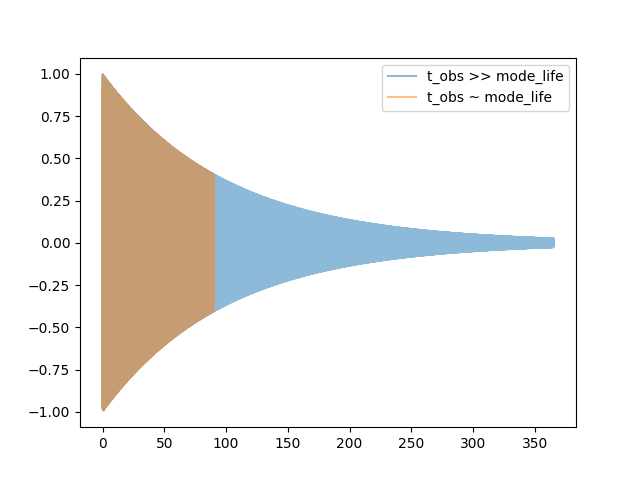

In [676]:
t_obs = 365*24*60*60
t_obs2 = 90*24*60*60
del_obs = 30*60
t_samp = np.arange(0,t_obs+del_obs,del_obs)
t_samp2 = np.arange(0,t_obs2+del_obs,del_obs)

life_samp = 100*(24*60*60)
signal = exp_decay(t_samp,tau=life_samp)
signal2 = exp_decay(t_samp2,tau=life_samp)
plt.figure()
plt.plot(t_samp/(60*60*24),signal,alpha=0.5,label='t_obs >> mode_life')
plt.plot(t_samp2/(60*60*24),signal2,alpha=0.5,label='t_obs ~ mode_life')
plt.legend()
plt.show()

In [669]:
t_samp

array([       0,     1800,     3600, ..., 31532400, 31534200, 31536000])

In [670]:
signal_fft = scipy.fft.fft(signal)
signal_freq = scipy.fft.fftfreq(len(signal),t_samp[-1]/t_samp.shape[0])
# signal_freq

In [671]:
signal2_fft = scipy.fft.fft(signal2)
signal_freq2 = scipy.fft.fftfreq(len(signal2),t_samp2[-1]/t_samp2.shape[0])

In [672]:
1e6*signal_freq2[(signal_freq2>98/1e6)&(signal_freq2<102/1e6)]

array([ 98.12242798,  98.25102881,  98.37962963,  98.50823045,
        98.63683128,  98.7654321 ,  98.89403292,  99.02263374,
        99.15123457,  99.27983539,  99.40843621,  99.53703704,
        99.66563786,  99.79423868,  99.92283951, 100.05144033,
       100.18004115, 100.30864198, 100.4372428 , 100.56584362,
       100.69444444, 100.82304527, 100.95164609, 101.08024691,
       101.20884774, 101.33744856, 101.46604938, 101.59465021,
       101.72325103, 101.85185185, 101.98045267])

In [673]:
psd = np.abs(signal_fft)
psd2 = np.abs(signal2_fft)

norm_psd = np.sum(np.abs(signal_fft))/len(signal_fft)/(np.sum(psd))
norm_psd2 = np.sum(np.abs(signal2_fft))/len(signal2_fft)/(np.sum(psd2))

In [674]:
np.sum(np.abs(signal_fft))/len(signal_fft)

3.091566657876296

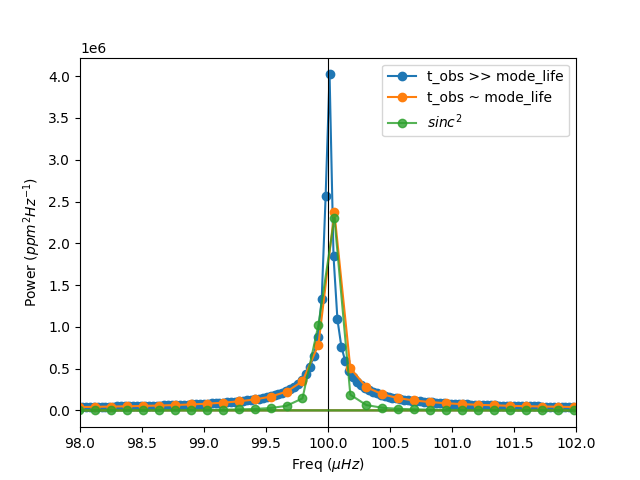

In [675]:
plt.figure()
plt.plot(signal_freq*1e6,norm_psd*psd*t_obs,'o-',label='t_obs >> mode_life')
plt.plot(signal_freq2*1e6,norm_psd2*psd2*t_obs2,'o-',label='t_obs ~ mode_life')
plt.axvline(100,linewidth=0.8,color='black')
plt.xlabel(r'Freq ($\mu Hz$)')
plt.ylabel(r'Power ($ppm^{2}Hz^{-1}$)')
plt.plot(signal_freq2*1e6,np.max(norm_psd*psd*t_obs)*np.sinc(signal_freq2*t_obs2-t_obs2*100*1e-6)**2,'o-',alpha=0.8,label=r'$sinc^2$')
plt.xlim(98,102)
plt.legend()
plt.show()